# Time-Varying Break-Even Growth Rate In Statsmodels

This notebook reproduces the core idea in `statsmodels` using a built-in local-level state-space model. That is the direct counterpart to a time-varying intercept with a random walk: the latent level is the intercept, and GDP growth plus the two COVID pulse dummies enter as fixed regressors.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / 'data').exists() else CWD.parent
DATA_PATH = PROJECT_ROOT / 'data' / 'prepared' / 'analysis_dataset_quarterly.csv'
OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'time_varying_break_even_statsmodels.csv'

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

## Load Dataset

In [2]:
analysis_df = pd.read_csv(DATA_PATH, parse_dates=['date'])

state_df = analysis_df.loc[:, ['date', 'U', 'Y']].copy()
state_df['Y_lag1'] = state_df['Y'].shift(1)
state_df['Y_lag2'] = state_df['Y'].shift(2)
state_df['d2020q2'] = (state_df['date'] == pd.Timestamp('2020-04-01')).astype(float)
state_df['d2020q3'] = (state_df['date'] == pd.Timestamp('2020-07-01')).astype(float)
state_df = state_df.dropna().reset_index(drop=True)

state_df.head()

,date,U,Y,Y_lag1,Y_lag2,d2020q2,d2020q3
0,1992-07-01,0.459021,-0.726074,-0.085709,0.570575,0.0,0.0
1,1992-10-01,0.586024,-0.501668,-0.726074,-0.085709,0.0,0.0
2,1993-01-01,0.505504,-0.332376,-0.501668,-0.726074,0.0,0.0
3,1993-04-01,0.544153,0.917484,-0.332376,-0.501668,0.0,0.0
4,1993-07-01,0.405117,0.381316,0.917484,-0.332376,0.0,0.0


## Static OLS Benchmark

In [3]:
X_ols = sm.add_constant(state_df[['Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']])
ols_result = sm.OLS(state_df['U'], X_ols).fit()

sigma_ols = float(ols_result.resid.std(ddof=int(ols_result.df_model) + 1))
std_eta_fixed = 0.05 * sigma_ols
static_break_even_qoq = -ols_result.params['const'] / (ols_result.params['Y'] + ols_result.params['Y_lag1'] + ols_result.params['Y_lag2'])
static_break_even_annualized = ((1 + static_break_even_qoq / 100) ** 4 - 1) * 100

pd.DataFrame({
    'parameter': ['const', 'b0', 'b1', 'b2', 'g2', 'g3', 'sigma_ols', 'std_eta_fixed', 'static_break_even_qoq', 'static_break_even_annualized'],
    'estimate': [
        ols_result.params['const'],
        ols_result.params['Y'],
        ols_result.params['Y_lag1'],
        ols_result.params['Y_lag2'],
        ols_result.params['d2020q2'],
        ols_result.params['d2020q3'],
        sigma_ols,
        std_eta_fixed,
        static_break_even_qoq,
        static_break_even_annualized,
    ],
})

,parameter,estimate
0,const,0.125988
1,b0,-0.088044
2,b1,-0.109339
3,b2,-0.074553
4,g2,0.104101
5,g3,-0.370653
6,sigma_ols,0.157520
7,std_eta_fixed,0.007876
8,static_break_even_qoq,0.463299
9,static_break_even_annualized,1.866113


## Statsmodels Local-Level Specification

Measurement equation:

`U_t = c_t + beta_0 Y_t + beta_1 Y_{t-1} + beta_2 Y_{t-2} + gamma_2 D_{2020Q2,t} + gamma_3 D_{2020Q3,t} + eps_t`

State equation:

`c_t = c_{t-1} + eta_t`

In `statsmodels`, this is implemented as an `UnobservedComponents` model with a stochastic local level and exogenous regressors. To make the comparison cleaner, we constrain the state innovation variance to match notebook 04: `sigma2.level = std_eta_fixed**2`.

In [4]:
exog = state_df[['Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']]
ucm = sm.tsa.UnobservedComponents(
    state_df['U'],
    level='local level',
    exog=exog,
)
ucm_result = ucm.fit_constrained({'sigma2.level': std_eta_fixed**2}, disp=False)
ucm_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Unobserved Components Results                         
==============================================================================
Dep. Variable:                      U   No. Observations:                  134
Model:                    local level   Log Likelihood                  58.384
Date:                Mon, 01 Jun 2026   AIC                           -104.767
Time:                        09:59:25   BIC                            -87.425
Sample:                             0   HQIC                           -97.720
                                - 134                                         
Covariance Type:                  opg                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
sigma2.irregular         0.0222      0.002      9.659      0.000       0.018       0.027
sigma2.level (fixed)  6.203e-05        nan        nan        nan         nan         nan
beta.Y                  -0.0864      0.024     -3.579      0.000      -0.134      -0.039
beta.Y_lag1             -0.1090      0.022     -4.890      0.000      -0.153      -0.065
beta.Y_lag2             -0.0740      0.010     -7.780      0.000      -0.093      -0.055
beta.d2020q2             0.1111      0.762      0.146      0.884      -1.382       1.604
beta.d2020q3            -0.3828      0.763     -0.502      0.616      -1.878       1.113
===================================================================================
Ljung-Box (L1) (Q):                  65.67   Jarque-Bera (JB):                21.13
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.28   Skew:                            -0.64
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

param_table = pd.DataFrame({
    'parameter': ucm_result.params.index,
    'estimate': ucm_result.params.values,
})
param_table

In [5]:
param_table = pd.DataFrame({
    'parameter': ucm_result.params.index,
    'estimate': ucm_result.params.values,
})
param_table

,parameter,estimate
0,sigma2.irregular,0.022156
1,sigma2.level,0.000062
2,beta.Y,-0.086437
3,beta.Y_lag1,-0.109001
4,beta.Y_lag2,-0.073952
5,beta.d2020q2,0.111089
6,beta.d2020q3,-0.382799


## Smoothed Level And Implied Break-Even Growth

In [6]:
smoothed_level = pd.Series(ucm_result.level.smoothed, index=state_df.index)
sum_beta = (
    ucm_result.params['beta.Y']
    + ucm_result.params['beta.Y_lag1']
    + ucm_result.params['beta.Y_lag2']
)

results_df = state_df.copy()
results_df['c_t'] = smoothed_level
results_df['break_even_growth_qoq_pct'] = -results_df['c_t'] / sum_beta
results_df['break_even_growth_annualized_pct'] = ((1 + results_df['break_even_growth_qoq_pct'] / 100) ** 4 - 1) * 100
results_df['static_break_even_qoq_pct'] = static_break_even_qoq
results_df['static_break_even_annualized_pct'] = static_break_even_annualized

results_df[['c_t', 'break_even_growth_qoq_pct', 'break_even_growth_annualized_pct']].describe().T

,count,mean,std,min,25%,50%,75%,max
c_t,134.0,0.124916,0.013191,0.091142,0.118316,0.124338,0.134396,0.153673
break_even_growth_qoq_pct,134.0,0.463701,0.048968,0.338327,0.439198,0.461552,0.498890,0.570450
break_even_growth_annualized_pct,134.0,1.867887,0.198530,1.360190,1.768401,1.859030,2.010542,2.301398


## Scenario Paths

In [7]:
gdp_growth_2pct_annualized_qoq = ((1 + 0.02) ** 0.25 - 1) * 100

results_df['implied_U_if_gdp_0_qoq_pp'] = results_df['c_t']
results_df['implied_U_if_gdp_2pct_ann_qoq_pp'] = results_df['c_t'] + sum_beta * gdp_growth_2pct_annualized_qoq

pd.DataFrame({
    'scenario': ['GDP stagnation', 'GDP growth at 2% annualised'],
    'assumed_gdp_qoq_pct': [0.0, gdp_growth_2pct_annualized_qoq],
    'mean_implied_U_change_pp': [
        results_df['implied_U_if_gdp_0_qoq_pp'].mean(),
        results_df['implied_U_if_gdp_2pct_ann_qoq_pp'].mean(),
    ],
})

,scenario,assumed_gdp_qoq_pct,mean_implied_U_change_pp
0,GDP stagnation,0.000000,0.124916
1,GDP growth at 2% annualised,0.496293,-0.008780


## Plots

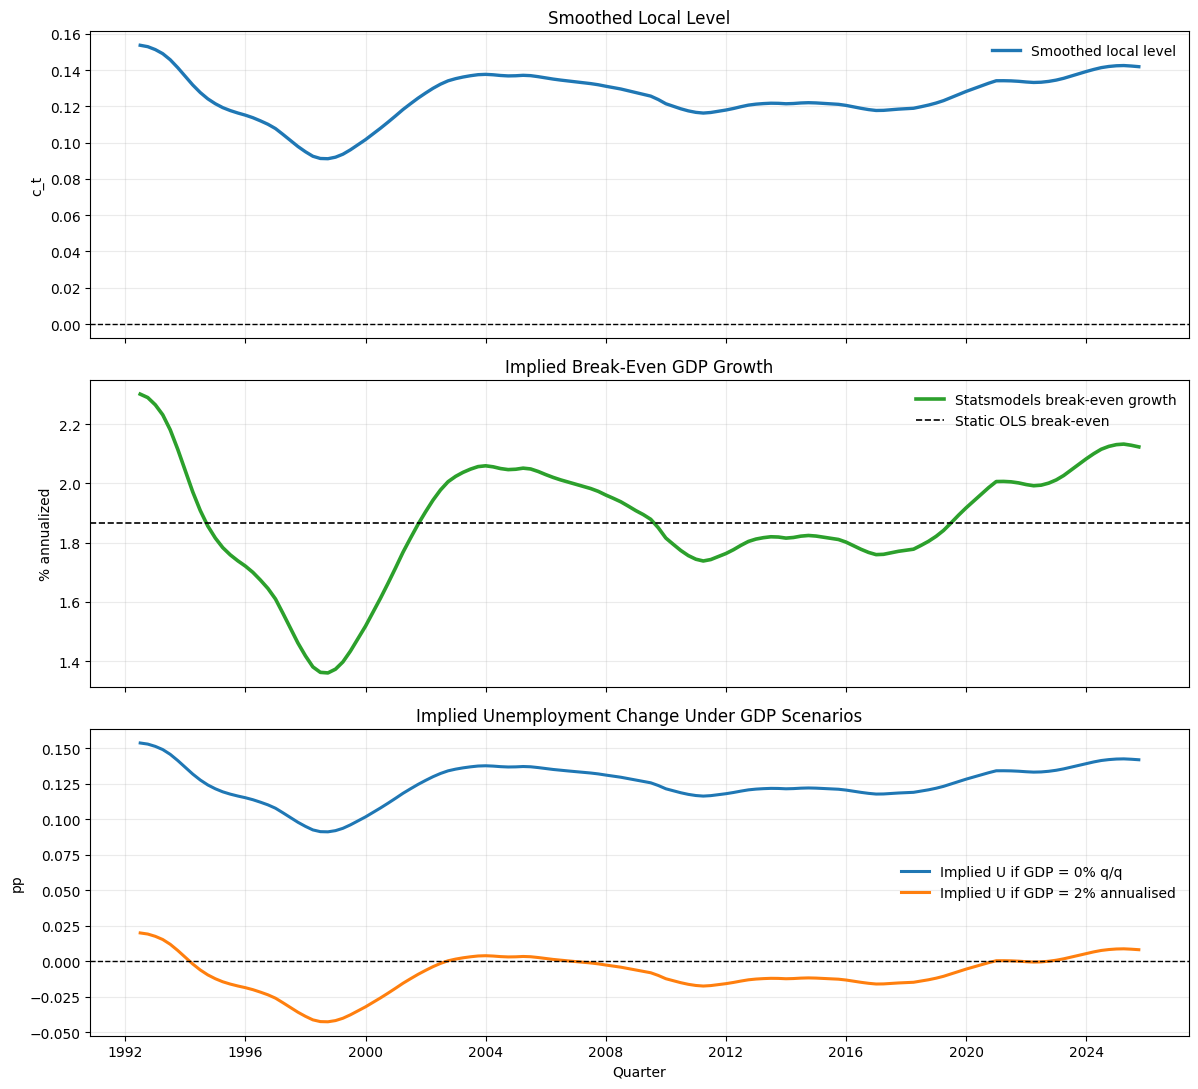

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
axes[0].plot(results_df['date'], results_df['c_t'], color='tab:blue', linewidth=2.4, label='Smoothed local level')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Smoothed Local Level')
axes[0].set_ylabel('c_t')
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(results_df['date'], results_df['break_even_growth_annualized_pct'], color='tab:green', linewidth=2.6, label='Statsmodels break-even growth')
axes[1].axhline(static_break_even_annualized, color='black', linestyle='--', linewidth=1.2, label='Static OLS break-even')
axes[1].set_title('Implied Break-Even GDP Growth')
axes[1].set_ylabel('% annualized')
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

axes[2].plot(results_df['date'], results_df['implied_U_if_gdp_0_qoq_pp'], linewidth=2.2, label='Implied U if GDP = 0% q/q')
axes[2].plot(results_df['date'], results_df['implied_U_if_gdp_2pct_ann_qoq_pp'], linewidth=2.2, label='Implied U if GDP = 2% annualised')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1.0)
axes[2].set_title('Implied Unemployment Change Under GDP Scenarios')
axes[2].set_ylabel('pp')
axes[2].set_xlabel('Quarter')
axes[2].grid(alpha=0.25)
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

## Save Results

In [9]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(OUTPUT_PATH, index=False)
OUTPUT_PATH

PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/outputs/time_varying_break_even_statsmodels.csv')